<a href="https://colab.research.google.com/github/danielmogo25/Proyecto-UNAL-ChatMP3/blob/main/Chat_mp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#importamos las librerias que vamos a usar
import requests
import sqlite3
import csv
from IPython.display import Audio
from IPython.display import Image, display
import pandas as pd
import time
from google.colab import files
import random

In [ ]:

#Creacion base de datos
conn = sqlite3.connect('base_datos_chat_mp3(2).sqlite')
cur=conn.cursor()
cur.executescript('''
CREATE TABLE IF NOT EXISTS Track(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
titulo TEXT UNIQUE,
artista INTEGER,
album INTEGER,
genero INTEGER,
duracion INTEGER,
fecha INTEGER,
preview TEXT,
imagen TEXT
);
CREATE TABLE IF NOT EXISTS Genero(
id INTEGER NOT NULL PRIMARY KEY AUTOINCREMENT UNIQUE,
nombre TEXT UNIQUE
)
''')
conn.commit()

In [ ]:
#SOLO PARA COLLAB
#archivos = files.upload()
#archivos1= files.upload()
# Obtener el nombre del archivo cargado automáticamente de el escritorio
#nombre_archivo = list(archivos.keys())[0]
#nombre_base_de_datos=list(archivos1.keys())[0]

Saving prueba - Hoja 1.csv to prueba - Hoja 1 (3).csv


Saving base_datos_chat_mp3(2).sqlite to base_datos_chat_mp3(2) (4).sqlite


In [3]:
def retorna_metacancion(termino):
    """
    Funcion que retorna la meta data de una cancion o artista(de la API  de I tunes) en una lista
    Entrada: Termino de busqueda(string)
    Salida: Lista con info cancion:
    [titulo, duracion, album, artista, fecha, genero, preview]

    """
    url = "https://itunes.apple.com/search"
    params = {
        "term": termino,
        "media": "music",
        "entity": "song",
        "limit": 1
    }
    respuesta_1 = requests.get(url, params=params, timeout=10)
    resultados = respuesta_1.json()["results"]  # esto es una LISTA

    if len(resultados) == 0:
        return None  # iTunes no encontró nada para ese término

    dato = resultados[0]  # <-- el fix: tomar el primer elemento

    titulo = dato.get('trackName')
    album = dato.get("collectionName")
    artista = dato.get('artistName')
    preview = dato.get('previewUrl')
    fecha = int(dato.get('releaseDate', '0000')[:4])
    genero = dato.get('primaryGenreName')
    milisegundos = dato.get('trackTimeMillis')
    imagen=dato.get('artworkUrl100')

    if milisegundos:
        minutos = milisegundos // 60000
        segundos = (milisegundos % 60000) // 1000
        duracion = f"{minutos}:{segundos:02d}"
    else:
        duracion = None

    return [titulo, duracion, album, artista, fecha, genero, preview,imagen]



In [5]:
def insertar_cancion(nombre_csv):
    """
    LEE CSV, LLAMA FUNCION QUE DEVUELVE META DATOS,
    INSERTA ESOS. DATOS EN LA BASE DE DATOS

    ENTRADA: NOMBRE CSV
    SALIDA. BASE DE DATOS LLENA

    """
    conn = sqlite3.connect('base_datos_chat_mp3(2).sqlite')
    cur = conn.cursor()

    count = 0
    nofound = 0

    with open(nombre_csv, "r", encoding="utf-8") as f:
        lector = csv.reader(f)

        for fila in lector:
            if count > 100:
                print('ya 100 canciones reiniciar para ingresar mas')
                break

            termino = fila[0].strip()
            if not termino:
                continue


            # Si el título ya está en Track, no volvemos a llamar a la API
            cur.execute("SELECT id FROM Track WHERE titulo = ?", (termino,))
            if cur.fetchone() is not None:
                print("Ya encontrado en la base de. datos:", termino)
                continue
            time.sleep(0.3)

            print("Insertando:", termino)
            try:
                pieces = retorna_metacancion(termino)
            except Exception as e:
                print("==== Error consultando la API ====", e)
                continue

            count = count + 1

            if pieces is None:
                print("==== Objeto no encontrado ====")
                nofound = nofound + 1
                continue

            titulo, duracion, album, artista, fecha, genero, preview, imagen = pieces

            # --- Genero ---
            cur.execute("INSERT OR IGNORE INTO Genero (nombre) VALUES (?)", (genero,))
            cur.execute("SELECT id FROM Genero WHERE nombre = ?", (genero,))
            genero_id = cur.fetchone()[0]

            # --- Track ---
            cur.execute('''INSERT OR IGNORE INTO Track
                (titulo, artista, album, duracion, fecha, preview, imagen,genero)
                VALUES (?, ?, ?, ?, ?, ?,?,?)''',
                (titulo, artista, album, duracion,fecha, preview,imagen,genero))

            conn.commit()

            print(f"Retrieved: {titulo} - {artista} ({duracion})")



    if nofound > 0:
        print('no encontrado', nofound)

    conn.close()
    print("QUERY base_datos_chat_mp3.sqlite para revisar")
#insertar_cancion(nombre_archivo)

In [8]:
def query_base_random(genero,duracion,decada):
  conn = sqlite3.connect('base_datos_chat_mp3(2).sqlite')
  cur = conn.cursor()
  if genero=="rap":
    parametros_genero=("Hip-Hop/Rap","Latin Rap","Rap")

  elif genero=="pop":
    parametros_genero=("Pop","Country","Reggae","K-Pop","Flamenco")

  elif genero=="rock":
    parametros_genero=("Indie Rock","Hard Rock","Rock","Rock y Alternativo","Metal")

  elif genero=="electronica":
    parametros_genero=("Dance","Electronic","House")

  if duracion=="menos":
    parametro_duracion1=0
    parametro_duracion2=180

  elif duracion=="entre":
    parametro_duracion1=180
    parametro_duracion2=240

  elif duracion=="mas":
    parametro_duracion1=180
    parametro_duracion2=200000

  if decada=="1990":
    parametro_decada1=1990
    parametro_decada2=1999

  elif decada=="2000":
    parametro_decada1=2000
    parametro_decada2=2009

  elif decada=="2010":
    parametro_decada1=2010
    parametro_decada2=2030
  cur.execute(f'''
    SELECT *
    FROM Track
    WHERE genero in {parametros_genero}
    AND (fecha BETWEEN {parametro_decada1} AND {parametro_decada2})
    AND (
              CAST(substr(duracion, 1, instr(duracion, ':') - 1) AS INTEGER) * 60
              + CAST(substr(duracion, instr(duracion, ':') + 1) AS INTEGER)
          ) BETWEEN {parametro_duracion1} AND {parametro_duracion2}

    ''')

  lista_canciones=[]

  for fila in cur.fetchall():
    #print(fila)
    lista_canciones.append(fila)

  return lista_canciones



query_base_random("rock","mas","2000")

OperationalError: no such table: Track

TITULO:Man In the Box (Live)
ALBUM:Live
ARTISTA:Alice In Chains
GENERO:Hard Rock
DURACION:4:48
AÑO SALIDA:2000


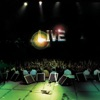

True

In [ ]:
def mostrar_cancion(lista_canciones):
  #LA tupla con la informacion de las canciones tiene los datos de estas
  lista_tuplas=list(lista_canciones)
  if len(lista_tuplas)==0:
    print("Tuvimos problemos en encontrar una cancion como la que buscas, intenta con otra")
    return False
  else:
    random.shuffle(lista_tuplas)

    id,titulo,artista,album,genero,duracion,fecha,preview,imagen=list(lista_tuplas[0])


    nombre_limpio=artista
    nombre_limpio = "".join(c for c in titulo if c.isalnum() or c in (" ", "_", "-")).rstrip()
    archivo_local = f"{nombre_limpio}.jpg"
    descargar_imagen(imagen, archivo_local)

    print("=" * 50)
    print(f"TITULO:{titulo}\nALBUM:{album}\nARTISTA:{artista}\nGENERO:{genero}\nDURACION:{duracion}\nAÑO SALIDA:{fecha}")
    display(Image(archivo_local))

    nombre_archivo = f"{nombre_limpio}Preview.m4a"
    try:
        info = requests.get(preview, timeout=10)
        info.raise_for_status()
        with open(nombre_archivo, "wb") as archi:
            archi.write(info.content)
        display(Audio(nombre_archivo))
    except requests.exceptions.Timeout:
        print(" La descarga del preview tardó demasiado y se canceló.")
    except requests.exceptions.RequestException as error:
        print(f" No se pudo descargar el preview: {error}")
    return True
canciones=[(41,
  'Man In the Box (Live)',
  'Alice In Chains',
  'Live',
  'Hard Rock',
  '4:48',
  2000,
  'https://audio-ssl.itunes.apple.com/itunes-assets/AudioPreview115/v4/33/33/04/333304da-a2ce-4aa4-7f72-22382024acc2/mzaf_16767841281870213403.plus.aac.p.m4a',
  'https://is1-ssl.mzstatic.com/image/thumb/Music/2f/47/fa/mzi.effcotrm.jpg/100x100bb.jpg'),
 (45,
  'Chop Suey!',
  'System Of A Down',
  'Toxicity',
  'Hard Rock',
  '3:30',
  2001,
  'https://audio-ssl.itunes.apple.com/itunes-assets/AudioPreview125/v4/f4/a1/c2/f4a1c207-6d73-e3bd-8fcb-bd6c5037021a/mzaf_16212608709217830172.plus.aac.p.m4a',
  'https://is1-ssl.mzstatic.com/image/thumb/Music125/v4/82/51/52/825152b4-9423-b23b-c036-cc67ead732d4/888888046775.jpg/100x100bb.jpg'),
 (46,
  'In the End',
  'LINKIN PARK',
  'Hybrid Theory (Deluxe Edition)',
  'Hard Rock',
  '3:36',
  2000,
  'https://audio-ssl.itunes.apple.com/itunes-assets/AudioPreview125/v4/3f/cb/c7/3fcbc7cc-0606-7f6e-7fc3-793318cfd1ed/mzaf_16081918663584534594.plus.aac.p.m4a',
  'https://is1-ssl.mzstatic.com/image/thumb/Music115/v4/53/a7/7f/53a77fab-c54c-a57b-8130-248fc12d0c80/093624948995.jpg/100x100bb.jpg'),
 (47,
  'No One Knows',
  'Queens of the Stone Age',
  'Songs for the Deaf',
  'Rock',
  '4:38',
  2002,
  'https://audio-ssl.itunes.apple.com/itunes-assets/AudioPreview125/v4/ee/f6/fd/eef6fd46-2c45-2b9b-427c-992485f62979/mzaf_559016003995192924.plus.aac.p.m4a',
  'https://is1-ssl.mzstatic.com/image/thumb/Music125/v4/50/ca/f8/50caf865-3197-77d3-f416-abfa14e698bd/00602517417205.rgb.jpg/100x100bb.jpg'),
 (72,
  'Mr. Brightside',
  'The Killers',
  'Direct Hits',
  'Rock',
  '3:43',
  2003,
  'https://audio-ssl.itunes.apple.com/itunes-assets/AudioPreview211/v4/c3/a0/30/c3a03008-17c5-aa29-6c6a-5e757ccdbaa5/mzaf_6073120660767081787.plus.aac.p.m4a',
  'https://is1-ssl.mzstatic.com/image/thumb/Music126/v4/11/64/9c/11649c80-2066-dba8-77a9-df7eecae26c1/17UM1IM06937.rgb.jpg/100x100bb.jpg'),
 (76,
  'Seven Nation Army',
  'The White Stripes',
  'Elephant',
  'Rock',
  '3:52',
  2003,
  'https://audio-ssl.itunes.apple.com/itunes-assets/AudioPreview115/v4/61/54/97/61549744-a83b-1c4d-58cf-e56b36beb4a7/mzaf_1246579179619940831.plus.aac.p.m4a',
  'https://is1-ssl.mzstatic.com/image/thumb/Music114/v4/07/25/09/0725098a-09f4-f240-e551-94384a590371/886448799009.jpg/100x100bb.jpg')]
mostrar_cancion(canciones)

In [ ]:
def descargar_imagen(url,nombre_archivo):
  """
    Descarga un archivo binario desde una URL y lo guarda en disco.

    Args:
        url (str): URL del archivo a descargar.
        nombre_archivo (str): nombre con el que se guardará localmente.

    Returns:
        bool: True si la descarga fue exitosa, False si falló.
    """

  try:
      respuesta = requests.get(url, stream=True, timeout=10)
      respuesta.raise_for_status()

      with open(nombre_archivo, "wb") as archivo:
          for bloque in respuesta.iter_content(chunk_size=8192):
              archivo.write(bloque)

      #print(f" Archivo guardado como '{nombre_archivo}'")
      return True

  except requests.exceptions.Timeout:
      print(" La descarga tardó demasiado y se canceló.")
  except requests.exceptions.RequestException as error:
      print(f" No se pudo descargar el archivo: {error}")

  return False

In [ ]:
def buscador_por_termino(termino, limite):
    url = "https://itunes.apple.com/search"
    params = {
        "term": termino,
        "media": "music",
        "entity": "song",
        "limit": limite
    }
    try:
        respuesta_1 = requests.get(url, params=params, timeout=10)
        respuesta_1.raise_for_status()
    except requests.exceptions.Timeout:
        print(" La búsqueda tardó demasiado y se canceló.")
        return
    except requests.exceptions.RequestException as error:
        print(f" No se pudo realizar la búsqueda: {error}")
        return

    print("CODIGO DE ESTADO", respuesta_1.status_code)
    resultados = respuesta_1.json()["results"]

    for dato in resultados:
        titulo = dato.get('trackName')
        album = dato.get("collectionName")
        artista = dato.get('artistName')
        preview = dato.get('previewUrl')
        fecha = int(dato.get('releaseDate')[:4])
        genero = dato.get('primaryGenreName')

        milisegundos = dato.get('trackTimeMillis')
        minutos = milisegundos // 60000
        segundos = (milisegundos % 60000) // 1000
        duracion = f"{minutos}:{segundos:02d}"

        imagen_url = dato.get('artworkUrl100')
        nombre_limpio = "".join(c for c in titulo if c.isalnum() or c in (" ", "_", "-")).rstrip()
        archivo_local = f"{nombre_limpio}.jpg"
        descargar_imagen(imagen_url, archivo_local)

        print("=" * 50)
        print(f"TITULO:{titulo}\nALBUM:{album}\nARTISTA:{artista}\nGENERO:{genero}\nDURACION:{duracion}\nPREVIEW LINK:{preview}\nAÑO SALIDA:{fecha}")
        display(Image(archivo_local))

        nombre_archivo = f"{nombre_limpio}Preview.m4a"
        try:
            info = requests.get(preview, timeout=10)
            info.raise_for_status()
            with open(nombre_archivo, "wb") as archi:
                archi.write(info.content)
            display(Audio(nombre_archivo))
        except requests.exceptions.Timeout:
            print(" La descarga del preview tardó demasiado y se canceló.")
        except requests.exceptions.RequestException as error:
            print(f" No se pudo descargar el preview: {error}")

    conn.commit()   # confirma todas las inserciones de esta búsqueda

In [ ]:
buscador_por_termino("idilio", 1)

 No se pudo realizar la búsqueda: 403 Client Error: Forbidden for url: https://itunes.apple.com/search?term=idilio&media=music&entity=song&limit=1


In [1]:
#Base "IA"
def guardar_artista(term): #ARREGLAR
  while True:
    nombre_artista = input("Dime el nombre del artista que quieres escuchar: ")

    url = "https://itunes.apple.com/search"
    try:
        respuesta_1 = requests.get(url, params=term, timeout=10)
        respuesta_1.raise_for_status()
        buscador_por_termino(nombre_artista, 1)
        break
    except:
        print(f" No pudimos encontrar al artista que buscas,/n intenta con otro termino o con otro artista ")

#---------------------------------PREGUNTAS----------------------------------------------------------------------------------
def preguntas_gustos():
  print("Vale, como primera pregunta entre pop, rock, rap o electrónica cual es tu genero favorito?")
  while True:
    generos = ["pop", "rock", "rap", "electronica"]
    primera_respuesta = input()
    eleccion_1 = ""
    verificacion = False
    for i in range(len(generos)):
      if generos[i] in primera_respuesta:
        if eleccion_1 == "":
          eleccion_1 = generos[i]
          verificacion = True
        else:
          verificacion = False
          break
    if verificacion == False:
      print("No pude entender cual genero elegiste, intentalo de nuevo")
      continue
    break
  print("Como segunda pregunta entre que duración es tu preferida de las siguientes: menos de 3 min, entre 3 y 4, o 4 o mas")
  while True:
    claves_duraciones = ["menos", "entre", "mas"]
    segunda_respuesta = input()
    eleccion_2 = ""
    verificacion = False
    for i in range(len(claves_duraciones)):
      if claves_duraciones[i] in segunda_respuesta:
        if eleccion_2 == "":
          eleccion_2 = claves_duraciones[i]
          verificacion = True
        else:
          verificacion = False
          break
    if verificacion == False:
      print("No pude entender cual duracion elegiste, intentalo de nuevo")
      continue
    break
  print("Como tercera pregunta, ¿cual decada de musica prefieres: los 90, los 2000 o del 2010 en adelante?")
  while True:
    claves_decadas = ["1990", "2000", "2010"]
    tercera_respuesta = input()
    eleccion_3 = ""
    verificacion = False
    for i in range(len(claves_decadas)):
      if claves_decadas[i] in tercera_respuesta:
        if eleccion_3 == "":
          eleccion_3 = claves_decadas[i]
          verificacion = True
        else:
          verificacion = False
          break
    if verificacion == False:
      print("No pude entender cual decada elegiste, intentalo de nuevo")
      continue
    break
  mostrar_cancion(query_base_random( eleccion_1, eleccion_2, eleccion_3))
  pass
  #--------------------------MAIN-------------------------------------------------------------------------
def main_chat():
  print("Hola, bienvenido a chatMP3! Estoy para ayudarte a encontrar tus nuevas canciones favoritas")
  nombre = input("¿Cuál es tu nombre? ").strip()
  print("Puedo buscar canciones en base preguntas generales sobre tus gustos musicales o en base a un artista especifico\n")

  while True:
    primera_eleccion = False
    segunda_eleccion = False
    tercera_eleccion = False

    print(f"Dime {nombre}, cual opcion deseas (por artista o preguntas) o tambien salir del programa: ")
    respuesta = input()

    if "artista" in respuesta or "cantante" in respuesta or "primera" in respuesta or "1" in respuesta or "uno" in respuesta:
      primera_eleccion = True
    if "pregunta" in respuesta or "gustos" in respuesta or "segunda" in respuesta or "2" in respuesta or "dos" in respuesta:
      segunda_eleccion = True
    if "sal" in respuesta or "cerrar" in respuesta or "cierra" in respuesta or "tercera" in respuesta or "3" in respuesta or "tres" in respuesta:
      tercera_eleccion = True

    if primera_eleccion == True and segunda_eleccion == True:
      print("Perdon, no pude entender cual opcion deseas (evita usar ambas palabras clave)")
    elif primera_eleccion == True:
      print("Entendido, recomendare a un artista en especifico\n")
      guardar_artista()
      break
    elif segunda_eleccion == True:
      print("Entendido, recomendare con preguntas sobre tus gustos musicales\n")
      #<<----------SE BUSCA UNA CANCION DE ACUERDO A LAS PREFERENCIAS----------<<
      preguntas_gustos()
      break
    elif tercera_eleccion == True:
      print("Entendido, saliendo del programa, hasta luego!")
      return
    else:
      print("Perdon, no pude entender cual opcion deseas (usa una palabra clave)")

main_chat()

Hola, bienvenido a chatMP3! Estoy para ayudarte a encontrar tus nuevas canciones favoritas
¿Cuál es tu nombre? juan
Puedo buscar canciones en base preguntas generales sobre tus gustos musicales o en base a un artista especifico

Dime juan, cual opcion deseas (por artista o preguntas) o tambien salir del programa: 
artista
Entendido, recomendare a un artista en especifico



TypeError: guardar_artista() missing 1 required positional argument: 'term'